<a href="https://colab.research.google.com/github/carlosjimenezortega/Projects/blob/main/PAS%20implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

**Función Núcleo para el PAS:**

Será la siguiente función simular_PAS

In [ ]:
def simular_PAS(p,n,reps=1):

  # Input:
  # p: es la probabilidad que hay de tomar el valor 1 en cada caso. Entre 0 y 1.
  # n: es el número de pasos a simular para cada trayectoria. Número natural.
  # reps: es el número de trayectorias a simular. Número natural.

  # Output:
  # Nos devolverá un array de dimensinalidad (reps,n), con los valores del PAS
  # en cada paso para cada trayectoria.

  # Generamos la matriz aleatoria con valores entre 0 y 1 (tamaño reps,n)
  random_matrix = np.random.rand(reps,n)

  # Transformamos la matriz con  en valores entre -1 y 1 con prob p.
  # Valores menores que p->1 y valores mayores o iguales->-1.
  pasos = np.where(random_matrix < p, 1, -1)

  # Usamos cumsum para tener el valor del PAS en el paso que queremos.
  trayectorias = np.cumsum(pasos, axis=1)

  return trayectorias



EJEMPLO FUNCIÓN simular_PAS:

In [ ]:
# Escribimos los valores concretos del ejemplo

p = 0.5
n_pasos = 5
n_reps = 3

# Aplicamos la función

simulacion = simular_PAS(p, n_pasos, n_reps)

# Imprimimos el la matriz que nos muestra el PAS (3x5):

print(simulacion)

[[-1 -2 -3 -4 -5]
 [ 1  0 -1 -2 -1]
 [-1 -2 -3 -2 -1]]


Con nuestra función núcleo ahora podemos graficar.

**PRIMERAS GRÁFICAS: diferentes trayectorias del PAS (sin media ni desviación típica teóricas):**

**GRÁFICA para p=0.5**

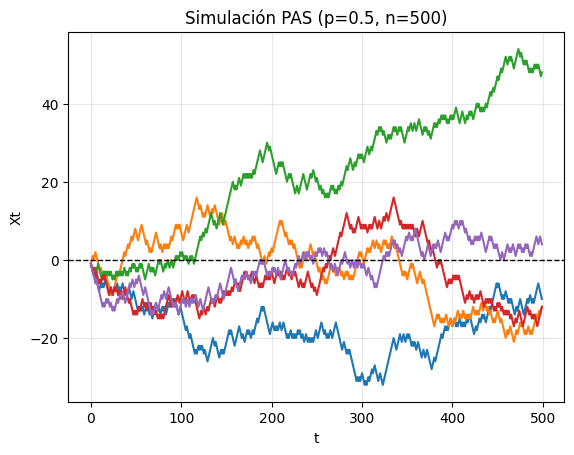

In [ ]:
# Definimos los parámetros de la primera gráfica
p = 0.5
n_pasos1 = 500
n_reps1 = 5

# Simulamos
trayectoria1 = simular_PAS(p, n_pasos1, n_reps1)

# Graficamos con Matplotlib

# Iteramos sobre cada una de las 5 trayectorias para graficarlas
for i in range(n_reps1):
      plt.plot(trayectoria1[i])

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0
plt.title(f"Simulación PAS (p={p}, n={n_pasos1})") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**GRÁFICA para p=0.6**

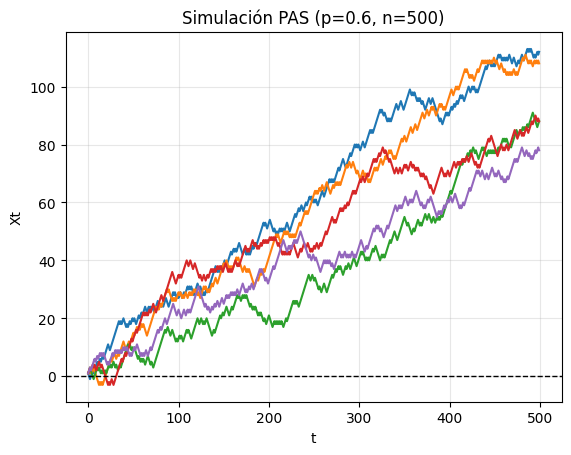

In [ ]:
# Definimos los parámetros de la segunda gráfica
p = 0.6
n_pasos1 = 500
n_reps1 = 5

# Simulamos
trayectoria1 = simular_PAS(p, n_pasos1, n_reps1)

# Graficamos con Matplotlib

# Iteramos sobre cada una de las 5 trayectorias para graficarlas
for i in range(n_reps1):
      plt.plot(trayectoria1[i])

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0
plt.title(f"Simulación PAS (p={p}, n={n_pasos1})") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**GRÁFICA para p=0.4**

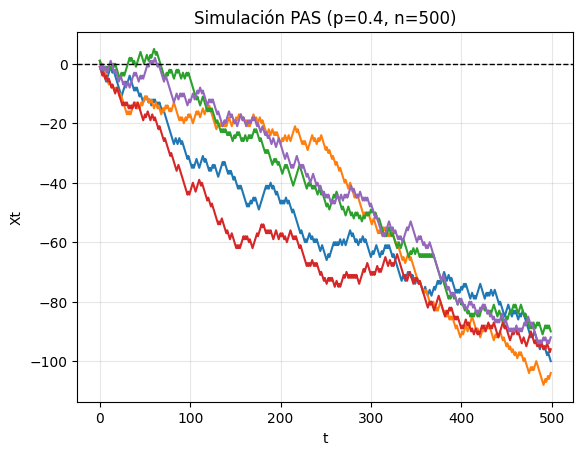

In [ ]:
# Definimos los parámetros de la tercera gráfica
p = 0.4
n_pasos1 = 500
n_reps1 = 5

# Simulamos
trayectoria1 = simular_PAS(p, n_pasos1, n_reps1)

# Graficamos con Matplotlib

# Iteramos sobre cada una de las 5 trayectorias para graficarlas
for i in range(n_reps1):
      plt.plot(trayectoria1[i])

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0
plt.title(f"Simulación PAS (p={p}, n={n_pasos1})") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**SEGUNDAS GRÁFICAS: diferentes trayectorias del PAS (con media y desviación típica teóricas):**

**GRÁFICA para p=0.5**

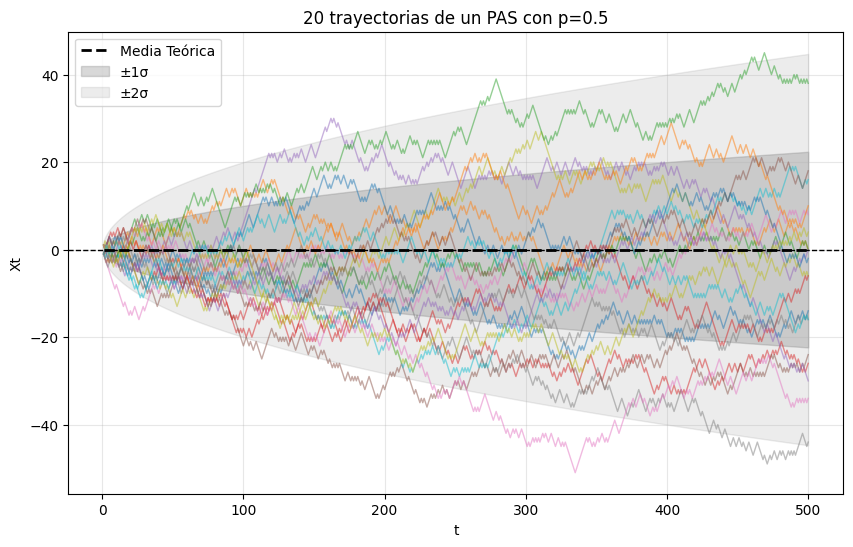

In [ ]:
# Definimos los parámetros de la cuarta gráfica
p = 0.5
n_pasos2 = 500
n_reps2 = 20

# Simulamos
trayectoria2 = simular_PAS(p, n_pasos2, n_reps2)
t = np.arange(1, n_pasos2 + 1) #array para crear secuencia de t

# Cálculos teóricos para la media y desviación típica
media_paso = 2 * p - 1
var_paso = 4 * p * (1 - p)

media_teorica = t * media_paso
desvtip_teorica = np.sqrt(t * var_paso)

# Graficamos con Matplotlib
plt.figure(figsize=(10, 6))

# Iteramos sobre cada una de las 20 trayectorias para graficarlas
for i in range(n_reps2):
    plt.plot(t, trayectoria2[i], alpha=0.5, linewidth=1)

# Media teórica
plt.plot(t, media_teorica, color='black',linestyle='--', label='Media Teórica', linewidth=2)

# Entornos de desviación típica
plt.fill_between(t, media_teorica - desvtip_teorica, media_teorica + desvtip_teorica,
                 color='gray', alpha=0.3, label='±1σ')
plt.fill_between(t, media_teorica - 2*desvtip_teorica, media_teorica + 2*desvtip_teorica,
                 color='gray', alpha=0.15, label='±2σ')

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0 negra y discontinua
plt.title(f"20 trayectorias de un PAS con p={p}") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**GRÁFICA para p=0.75**

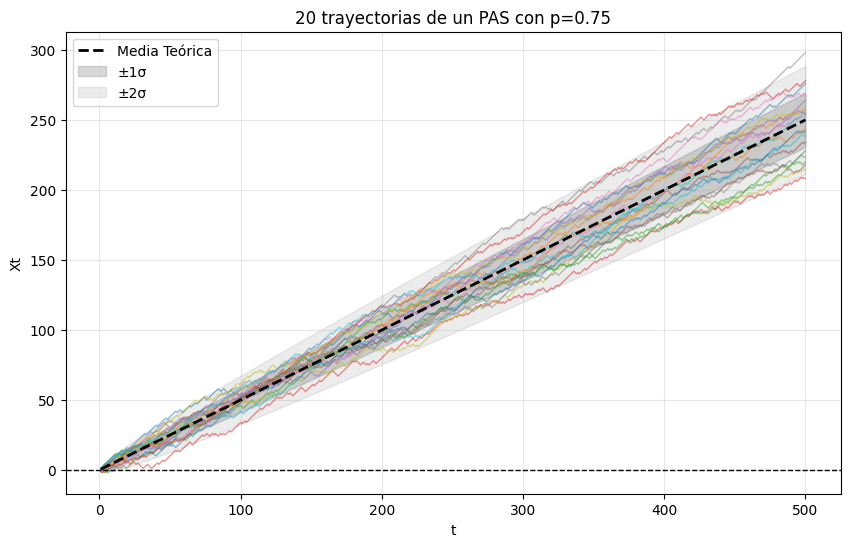

In [ ]:
# Definimos los parámetros de la quinta gráfica
p = 0.75
n_pasos2 = 500
n_reps2 = 20

# Simulamos
trayectoria2 = simular_PAS(p, n_pasos2, n_reps2)
t = np.arange(1, n_pasos2 + 1) #array para crear secuencia de t

# Cálculos teóricos para la media y desviación típica
media_paso = 2 * p - 1
var_paso = 4 * p * (1 - p)

media_teorica = t * media_paso
desvtip_teorica = np.sqrt(t * var_paso)

# Graficamos con Matplotlib
plt.figure(figsize=(10, 6))

# Iteramos sobre cada una de las 20 trayectorias para graficarlas
for i in range(n_reps2):
    plt.plot(t, trayectoria2[i], alpha=0.5, linewidth=1)

# Media teórica
plt.plot(t, media_teorica, color='black',linestyle='--', label='Media Teórica', linewidth=2)

# Entornos de desviación típica
plt.fill_between(t, media_teorica - desvtip_teorica, media_teorica + desvtip_teorica,
                 color='gray', alpha=0.3, label='±1σ')
plt.fill_between(t, media_teorica - 2*desvtip_teorica, media_teorica + 2*desvtip_teorica,
                 color='gray', alpha=0.15, label='±2σ')

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0 negra y discontinua
plt.title(f"20 trayectorias de un PAS con p={p}") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**GRÁFICA para p=0.95**

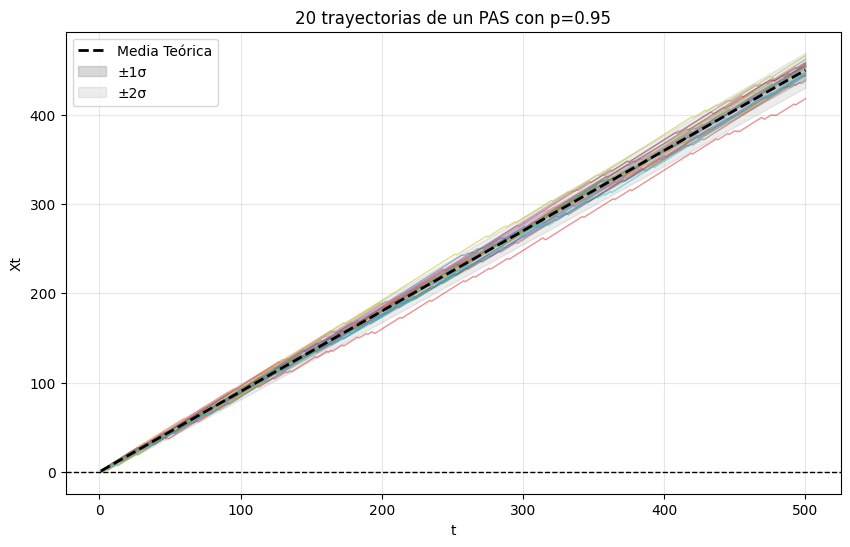

In [ ]:
# Definimos los parámetros de la sexta gráfica
p = 0.95
n_pasos2 = 500
n_reps2 = 20

# Simulamos
trayectoria2 = simular_PAS(p, n_pasos2, n_reps2)
t = np.arange(1, n_pasos2 + 1) #array para crear secuencia de t

# Cálculos teóricos para la media y desviación típica
media_paso = 2 * p - 1
var_paso = 4 * p * (1 - p)

media_teorica = t * media_paso
desvtip_teorica = np.sqrt(t * var_paso)

# Graficamos con Matplotlib
plt.figure(figsize=(10, 6))

# Iteramos sobre cada una de las 20 trayectorias para graficarlas
for i in range(n_reps2):
    plt.plot(t, trayectoria2[i], alpha=0.5, linewidth=1)

# Media teórica
plt.plot(t, media_teorica, color='black',linestyle='--', label='Media Teórica', linewidth=2)

# Entornos de desviación típica
plt.fill_between(t, media_teorica - desvtip_teorica, media_teorica + desvtip_teorica,
                 color='gray', alpha=0.3, label='±1σ')
plt.fill_between(t, media_teorica - 2*desvtip_teorica, media_teorica + 2*desvtip_teorica,
                 color='gray', alpha=0.15, label='±2σ')

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en el 0 negra y discontinua
plt.title(f"20 trayectorias de un PAS con p={p}") # Título de arriba
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("Xt") # Etiqueta eje y
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()

**ÚLTIMA GRÁFICA: media empírica del PAS cuando aumentamos las trayectorias (junto con la teórica):**

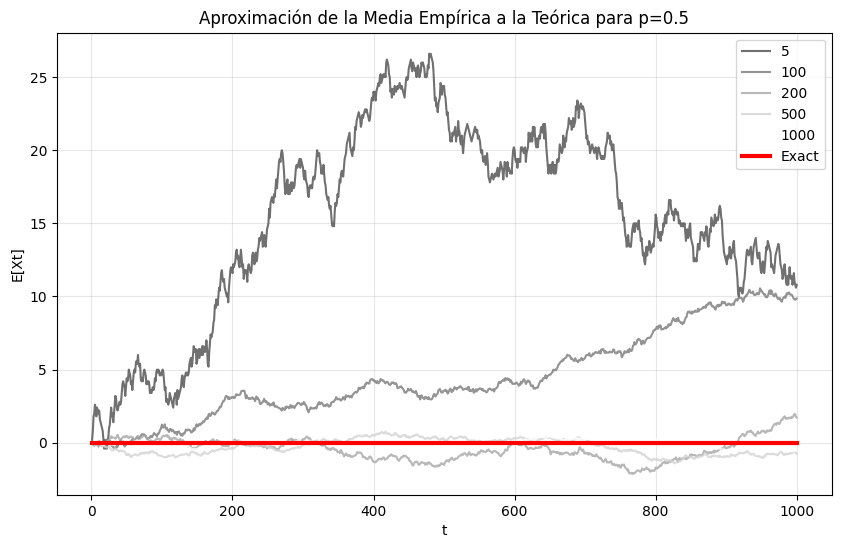

In [ ]:
# Definimos los parámetros de la séptima gráfica
p = 0.5
n_pasos3 = 1000
t = np.arange(1, n_pasos3 + 1)

# Cálculos teóricos para la media
media_paso = 2 * p - 1
media_teorica = t * media_paso

# Tamaños de muestra para la media empírica
reps_list = [5, 100, 200, 500, 1000]

plt.figure(figsize=(10, 6))

# Escala de grises para la gráfica
colors = [plt.cm.gray(i) for i in np.linspace(0.3, 1, len(reps_list))]

# Bucle que grafica la media empírica para los n de nuestra lista
for i, n_reps in enumerate(reps_list):
    simulacion = simular_PAS(p, n_pasos, n_reps)
    media_empirica = np.mean(simulacion, axis=0) # Promedio trayectorias en cada tiempo
    plt.plot(t, media_empirica, color=colors[i], label=f'{n_reps}', alpha=0.8)

# Línea de referencia en el 0 roja y continua
plt.plot(t, media_teorica, color='red', linestyle='-', linewidth=3, label='Exact')

plt.title(f"Aproximación de la Media Empírica a la Teórica para p={p}")
plt.xlabel("t") # Etiqueta eje x
plt.ylabel("E[Xt]") # Etiqueta eje y
plt.legend()
plt.grid(True, alpha=0.3) # Cuadrícula de fondo
plt.show()